In [1]:
!pip install timm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import timm
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 64
EPOCHS = 10
LR = 3e-4
NUM_CLASSES = 100
EPS = 1e-8

In [3]:
transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.CIFAR100(
    root="./data", train=True, download=True, transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR100(
    root="./data", train=False, download=True, transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

100%|██████████| 169M/169M [00:02<00:00, 83.3MB/s] 


In [4]:
model = timm.create_model('vit_base_patch16_224', pretrained=True)

in_features = model.head.in_features
model.head = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR)

In [6]:
def get_cls_features(model, x):
    model.eval()
    with torch.no_grad():
        x = model.patch_embed(x)
        cls_token = model.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = model.pos_drop(x + model.pos_embed)

        for blk in model.blocks:
            x = blk(x)

        x = model.norm(x)
        cls_features = x[:, 0]

    return cls_features

In [7]:
def compute_nc_metrics(features, labels, classifier_weights):
    """
    Implements NC1, NC2, NC3 exactly with normalization.
    """
    features = features.cpu().numpy()
    labels = labels.cpu().numpy()
    W = classifier_weights.detach().cpu().numpy()

    K = len(np.unique(labels))
    d = features.shape[1]

    # ---- Compute class means ----
    class_means = []
    counts = []

    for k in range(K):
        class_k = features[labels == k]
        if len(class_k) == 0:
            continue
        mu_k = np.mean(class_k, axis=0)
        class_means.append(mu_k)
        counts.append(len(class_k))

    class_means = np.array(class_means)
    overall_mean = np.mean(features, axis=0)

    # ---- NC1: Tr(Sw) / Tr(Sb) ----
    Sw = 0.0
    for k in range(K):
        class_k = features[labels == k]
        mu_k = class_means[k]
        Sw += np.sum((class_k - mu_k) ** 2)

    Sb = np.sum((class_means - overall_mean) ** 2)
    nc1 = Sw / (Sb + EPS)

    # ---- NC2: ETF deviation ----
    M = class_means - overall_mean
    M = M / (np.linalg.norm(M, axis=1, keepdims=True) + EPS)

    G = M @ M.T

    ETF = np.full((K, K), -1/(K-1))
    np.fill_diagonal(ETF, 1)

    nc2 = np.linalg.norm(G - ETF, ord='fro')

    # ---- NC3: self-duality ----
    W_norm = W / (np.linalg.norm(W, axis=1, keepdims=True) + EPS)
    M_norm = M

    nc3 = np.linalg.norm(W_norm - M_norm, ord='fro')

    return nc1, nc2, nc3

In [8]:
def compute_relative_flatness(features, logits, labels, classifier_weights):
    """
    Relative flatness using trace approximation in penultimate layer.
    
    Based on:
    Tr(H) ≈ E[ ||f||^2 * p(1-p) ]
    normalized by ||W||^2
    """

    features = features.detach()
    logits = logits.detach()
    labels = labels.detach()

    probs = torch.softmax(logits, dim=1)

    # Gather correct class probabilities
    p_y = probs[torch.arange(len(labels)), labels]

    # Compute p(1-p)
    curvature_term = p_y * (1 - p_y)

    # Feature norm squared
    feat_norm_sq = torch.sum(features**2, dim=1)

    trace_estimate = torch.mean(feat_norm_sq * curvature_term)

    # Weight norm squared
    W = classifier_weights
    weight_norm_sq = torch.sum(W**2)

    relative_flatness = trace_estimate / (weight_norm_sq + EPS)

    return relative_flatness.item()

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

nc1_hist, nc2_hist, nc3_hist = [], [], []
flatness_hist = []

train_acc_hist, test_acc_hist = [], []

train_f1_macro_hist, test_f1_macro_hist = [], []
train_f1_weighted_hist, test_f1_weighted_hist = [], []

for epoch in range(EPOCHS):
    # ===================== TRAIN =====================
    model.train()
    total_loss = 0

    train_preds = []
    train_labels_all = []

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} [TRAIN]")

    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        train_preds.extend(preds.cpu().numpy())
        train_labels_all.extend(labels.cpu().numpy())

        train_bar.set_postfix(loss=loss.item())

    # ---- Train Metrics ----
    train_acc = np.mean(np.array(train_preds) == np.array(train_labels_all)) * 100
    train_f1_macro = f1_score(train_labels_all, train_preds, average='macro')
    train_f1_weighted = f1_score(train_labels_all, train_preds, average='weighted')

    train_acc_hist.append(train_acc)
    train_f1_macro_hist.append(train_f1_macro)
    train_f1_weighted_hist.append(train_f1_weighted)

    print(f"\nTrain Loss: {total_loss:.4f}")
    print(f"Train Acc: {train_acc:.2f}% | F1(macro): {train_f1_macro:.4f} | F1(weighted): {train_f1_weighted:.4f}")

    # ===================== TEST =====================
    model.eval()
    correct, total = 0, 0

    test_preds = []
    test_labels_all = []

    all_features = []
    all_labels = []
    all_logits = []

    test_bar = tqdm(test_loader, desc=f"Epoch {epoch+1} [TEST]")

    with torch.no_grad():
        for images, labels in test_bar:
            images, labels = images.to(device), labels.to(device)

            logits = model(images)
            _, predicted = torch.max(logits, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            test_preds.extend(predicted.cpu().numpy())
            test_labels_all.extend(labels.cpu().numpy())

            feats = get_cls_features(model, images)

            all_features.append(feats)
            all_labels.append(labels)
            all_logits.append(logits)

    # ---- Test Metrics ----
    test_acc = 100 * correct / total
    test_f1_macro = f1_score(test_labels_all, test_preds, average='macro')
    test_f1_weighted = f1_score(test_labels_all, test_preds, average='weighted')

    test_acc_hist.append(test_acc)
    test_f1_macro_hist.append(test_f1_macro)
    test_f1_weighted_hist.append(test_f1_weighted)

    print(f"\nTest Acc: {test_acc:.2f}% | F1(macro): {test_f1_macro:.4f} | F1(weighted): {test_f1_weighted:.4f}")

    # ===================== NC + FLATNESS =====================
    all_features = torch.cat(all_features)
    all_labels = torch.cat(all_labels)
    all_logits = torch.cat(all_logits)

    nc1, nc2, nc3 = compute_nc_metrics(
        all_features, all_labels, model.head.weight
    )

    nc1_hist.append(nc1)
    nc2_hist.append(nc2)
    nc3_hist.append(nc3)

    flatness = compute_relative_flatness(
        all_features, all_logits, all_labels, model.head.weight
    )
    flatness_hist.append(flatness)

    print(f"NC1: {nc1:.6f} | NC2: {nc2:.6f} | NC3: {nc3:.6f}")
    print(f"Relative Flatness: {flatness:.6f}")

Epoch 1 [TRAIN]: 100%|██████████| 782/782 [28:41<00:00,  2.20s/it, loss=2.98]



Train Loss: 3021.9031
Train Acc: 10.73% | F1(macro): 0.0982 | F1(weighted): 0.0982


Epoch 1 [TEST]: 100%|██████████| 157/157 [04:01<00:00,  1.54s/it]



Test Acc: 20.73% | F1(macro): 0.1891 | F1(weighted): 0.1891
NC1: 182.718643 | NC2: 40.690986 | NC3: 9.934082
Relative Flatness: 1.020811


Epoch 2 [TRAIN]: 100%|██████████| 782/782 [28:57<00:00,  2.22s/it, loss=2.78]


...


Test Acc: 50.25% | F1(macro): 0.5023 | F1(weighted): 0.5023
NC1: 305.059723 | NC2: 25.013321 | NC3: 7.425266
Relative Flatness: 1.548046


Epoch 10 [TRAIN]: 100%|██████████| 782/782 [28:58<00:00,  2.22s/it, loss=0.78] 



Train Loss: 557.4703
Train Acc: 77.74% | F1(macro): 0.7769 | F1(weighted): 0.7769


Epoch 10 [TEST]: 100%|██████████| 157/157 [04:01<00:00,  1.54s/it]



Test Acc: 49.78% | F1(macro): 0.4925 | F1(weighted): 0.4925
NC1: 327.230255 | NC2: 24.397932 | NC3: 7.506901
Relative Flatness: 1.492667


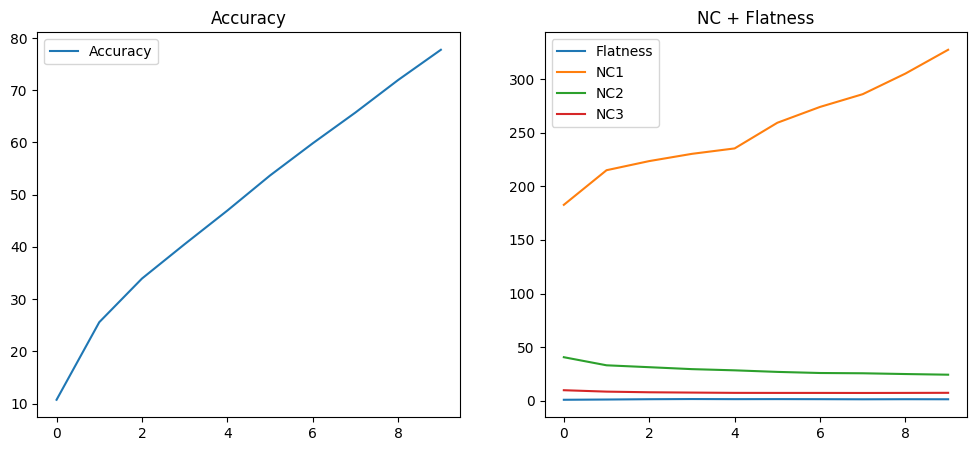

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_acc_hist, label="Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(flatness_hist, label="Flatness")
plt.plot(nc1_hist, label="NC1")
plt.plot(nc2_hist, label="NC2")
plt.plot(nc3_hist, label="NC3")
plt.legend()
plt.title("NC + Flatness")

plt.show()

Text(0.5, 1.0, 'Accuracy')

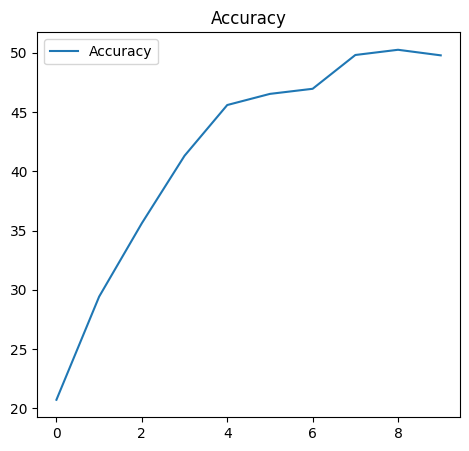

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(test_acc_hist, label="Accuracy")
plt.legend()
plt.title("Accuracy")

Text(0.5, 1.0, 'Accuracy')

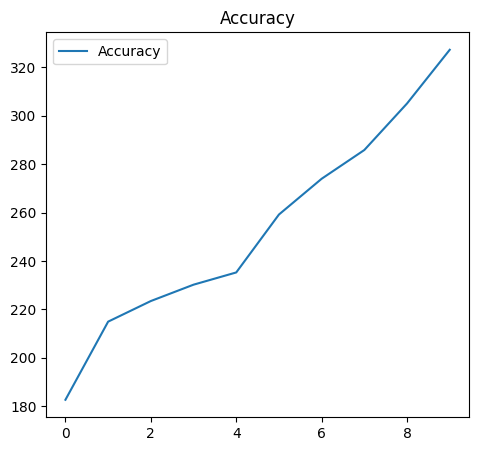

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(nc1_hist, label="Accuracy")
plt.legend()
plt.title("Accuracy")

Text(0.5, 1.0, 'Accuracy')

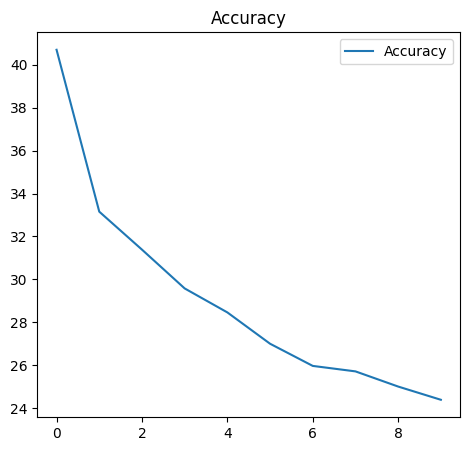

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(nc2_hist, label="Accuracy")
plt.legend()
plt.title("Accuracy")

Text(0.5, 1.0, 'Accuracy')

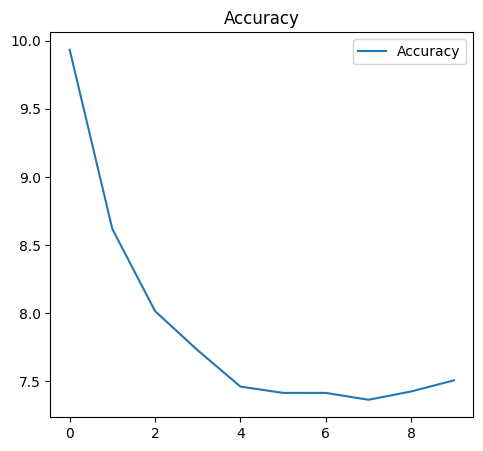

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(nc3_hist, label="Accuracy")
plt.legend()
plt.title("Accuracy")

Text(0.5, 1.0, 'Accuracy')

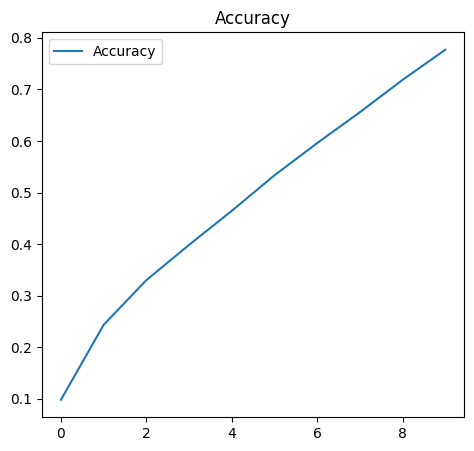

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_f1_macro_hist, label="Accuracy")
plt.legend()
plt.title("Accuracy")

Text(0.5, 1.0, 'Accuracy')

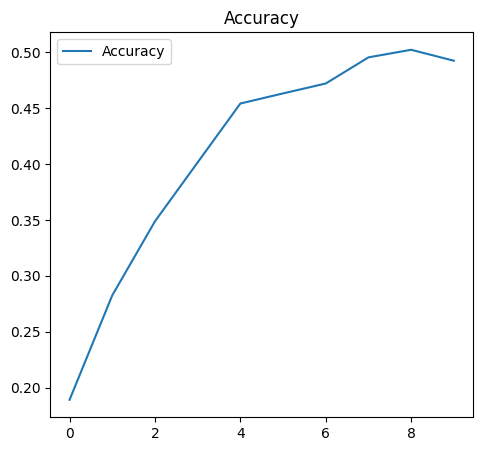

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(test_f1_macro_hist, label="Accuracy")
plt.legend()
plt.title("Accuracy")

Text(0.5, 1.0, 'Accuracy')

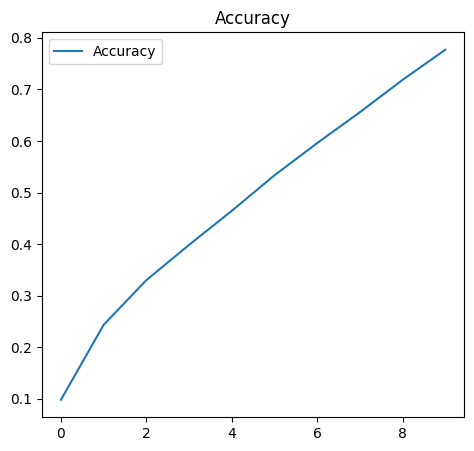

In [19]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_f1_weighted_hist, label="Accuracy")
plt.legend()
plt.title("Accuracy")

Text(0.5, 1.0, 'Accuracy')

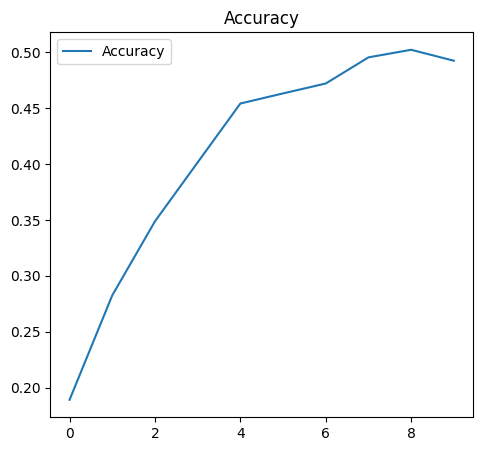

In [20]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(test_f1_weighted_hist, label="Accuracy")
plt.legend()
plt.title("Accuracy")

In [2]:
epochs = list(range(1, 11))

train_acc = [10.73, 25.59, 33.94, 40.52, 46.96, 53.68, 59.84, 65.73, 71.95, 77.74]
test_acc  = [20.73, 29.43, 35.62, 41.31, 45.59, 46.53, 46.96, 49.81, 50.25, 49.78]

train_f1 = [0.0982, 0.2435, 0.3301, 0.3985, 0.4646, 0.5334, 0.5959, 0.6558, 0.7185, 0.7769]
test_f1  = [0.1891, 0.2825, 0.3488, 0.4015, 0.4542, 0.4632, 0.4721, 0.4955, 0.5023, 0.4925]

nc1 = [182.718643, 214.980911, 223.487961, 230.241501, 235.291687,
       259.204010, 273.970825, 285.848419, 305.059723, 327.230255]

nc2 = [40.690986, 33.155394, 31.388022, 29.581572, 28.464824,
       27.006763, 25.974610, 25.719652, 25.013321, 24.397932]

nc3 = [9.934082, 8.617165, 8.014837, 7.726785, 7.460500,
       7.414614, 7.414465, 7.364012, 7.425266, 7.506901]

rf = [1.020811, 1.257948, 1.543918, 1.708121, 1.604110,
      1.641059, 1.575658, 1.463789, 1.548046, 1.492667]

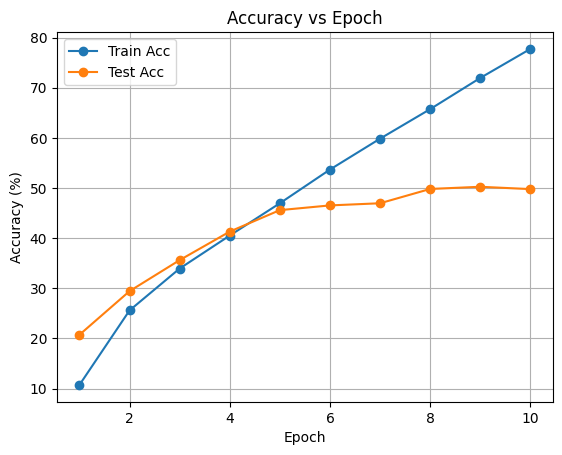

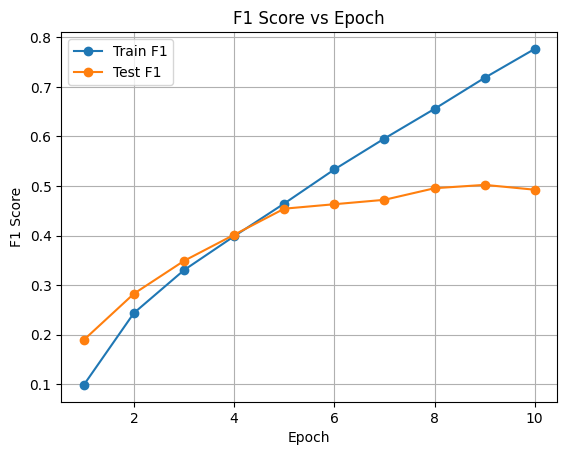

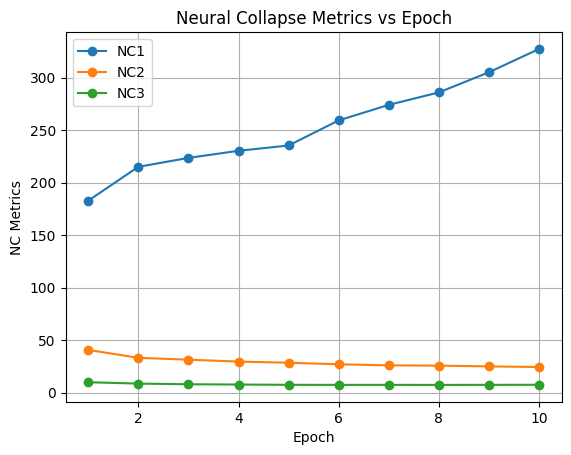

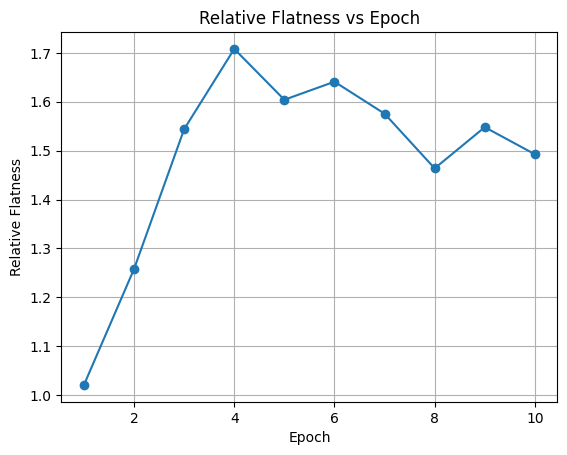

In [3]:
import matplotlib.pyplot as plt

# ── Figure 1: Accuracy ─────────────────────────────
plt.figure()
plt.plot(epochs, train_acc, marker='o', label='Train Acc')
plt.plot(epochs, test_acc, marker='o', label='Test Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid()
plt.show()


# ── Figure 2: F1 Score ─────────────────────────────
plt.figure()
plt.plot(epochs, train_f1, marker='o', label='Train F1')
plt.plot(epochs, test_f1, marker='o', label='Test F1')
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Epoch")
plt.legend()
plt.grid()
plt.show()


# ── Figure 3: Neural Collapse Metrics ──────────────
plt.figure()
plt.plot(epochs, nc1, marker='o', label='NC1')
plt.plot(epochs, nc2, marker='o', label='NC2')
plt.plot(epochs, nc3, marker='o', label='NC3')
plt.xlabel("Epoch")
plt.ylabel("NC Metrics")
plt.title("Neural Collapse Metrics vs Epoch")
plt.legend()
plt.grid()
plt.show()


# ── Figure 4: Relative Flatness ────────────────────
plt.figure()
plt.plot(epochs, rf, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Relative Flatness")
plt.title("Relative Flatness vs Epoch")
plt.grid()
plt.show()

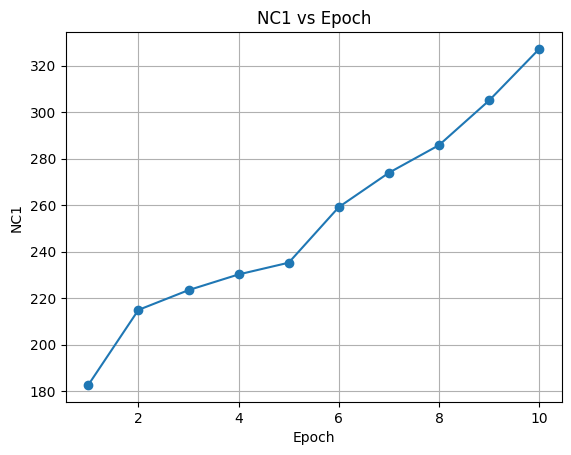

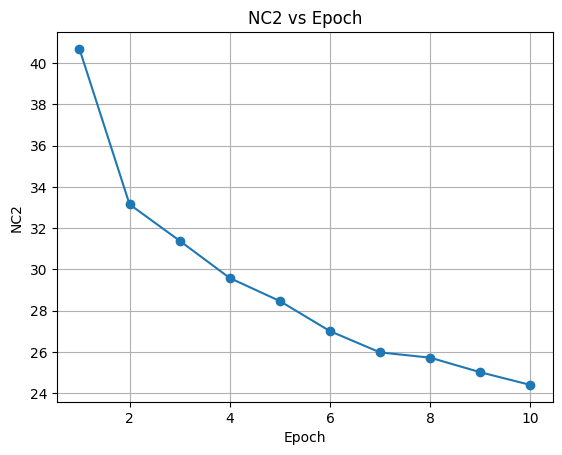

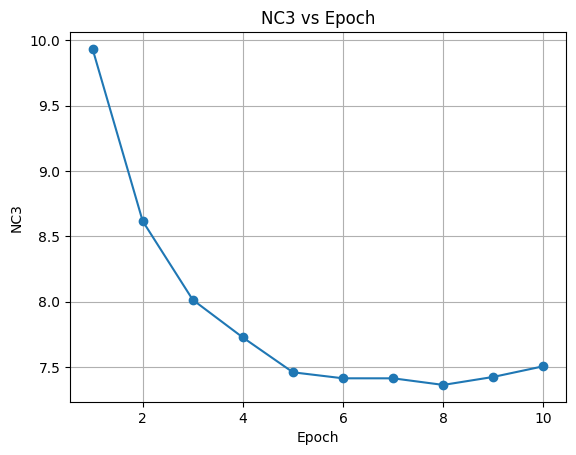

In [4]:
import matplotlib.pyplot as plt

# ── NC1 ─────────────────────────────
plt.figure()
plt.plot(epochs, nc1, marker='o')
plt.xlabel("Epoch")
plt.ylabel("NC1")
plt.title("NC1 vs Epoch")
plt.grid()
plt.show()


# ── NC2 ─────────────────────────────
plt.figure()
plt.plot(epochs, nc2, marker='o')
plt.xlabel("Epoch")
plt.ylabel("NC2")
plt.title("NC2 vs Epoch")
plt.grid()
plt.show()


# ── NC3 ─────────────────────────────
plt.figure()
plt.plot(epochs, nc3, marker='o')
plt.xlabel("Epoch")
plt.ylabel("NC3")
plt.title("NC3 vs Epoch")
plt.grid()
plt.show()